In [1]:
#1)Download Dataset

#https://drive.google.com/drive/folders/19zV45_NQzrBPLzFymXeNZiufxbeENGth

#2) Unzip

In [1]:
import cv2
import os
import numpy as np
import pandas as pd
from PIL import Image
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,GlobalMaxPooling2D
from keras.utils import load_img
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

In [3]:
Base_dir='datasets/UTKFace/'

In [4]:
images = os.listdir(Base_dir)

In [5]:
images[0]

'100_0_0_20170112213500903.jpg.chip.jpg'

In [6]:
image_paths = []
age_labels = []
gender_labels = []

for filename in images:
    image_path = os.path.join(Base_dir, filename)
    temp = filename.split('_')
    if str(temp[0]).isnumeric():
        age = int(temp[0])
        gender = int(temp[1])
        image_paths.append(image_path)
        age_labels.append(age)
        gender_labels.append(gender)

In [7]:
len(age_labels)

23708

In [8]:
def make_dataset(images):
    features = []
    for image in (images):
        img = load_img(image, grayscale=True)
        img = img.resize((128, 128), Image.LANCZOS)
        img = np.array(img)
        features.append(img)
        
    features = np.array(features)
    # ignore this step if using RGB
    features = features.reshape(len(features), 128, 128, 1)
    return features

In [9]:
X = make_dataset(image_paths)

c:\Users\RAB\AppData\Local\Programs\Python\Python38\lib\site-packages\keras\src\utils\image_utils.py:409: UserWarning: grayscale is deprecated. Please use color_mode = "grayscale"
  warnings.warn(


In [10]:
X.shape

(23708, 128, 128, 1)

In [11]:
X=X/255.0

In [15]:
Y= np.array(age_labels)

In [16]:
Y.shape

(23708,)

In [12]:
model= Sequential()

model.add(Conv2D(filters=16,kernel_size=(3,3),activation='relu',input_shape=(128,128,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu',input_shape=(128,128,1)))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())

model.add(Dense(units=32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

In [13]:
model.compile(loss='binary_crossentropy', optimizer='adam' , metrics=['accuracy'] )

In [17]:
X_train,X_test,y_train,y_test=train_test_split(X,Y,test_size=0.2)

In [18]:
X_train.shape

(18966, 128, 128, 1)

In [19]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

model.fit(X_train[:1000], y_train[:1000], epochs=3, batch_size=64, validation_data=(X_test[:200], y_test[:200]),
callbacks=[early_stop], verbose=1
)

Epoch 1/3
16/16 [==============================] - 515s 32s/step - loss: -2895.0833 - accuracy: 0.0430 - val_loss: -11434.0752 - val_accuracy: 0.0450
Epoch 2/3
16/16 [==============================] - 530s 33s/step - loss: -38227.7383 - accuracy: 0.0450 - val_loss: -94430.6016 - val_accuracy: 0.0450
Epoch 3/3
16/16 [==============================] - 405s 24s/step - loss: -212847.5000 - accuracy: 0.0450 - val_loss: -427618.1875 - val_accuracy: 0.0450


In [20]:
out=model.predict(X_test)

149/149 [==============================] - 539s 4s/step


In [21]:
out

array([[1.],
       [1.],
       [1.],
       ...,
       [1.],
       [1.],
       [1.]], dtype=float32)

In [22]:
y_test

array([16, 24, 70, ..., 22, 28, 54])

In [23]:
model.save_weights('model.h5')

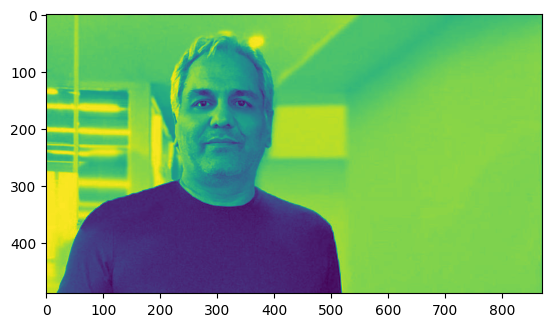

In [24]:
image_test=load_img('test.jpg',grayscale=True)

plt.close()

plt.imshow(image_test)

plt.show()


In [25]:
X_test[0].shape

(128, 128, 1)

Original Age: 88
1/1 [==============================] - 1s 1s/step
Predicted Age: 1


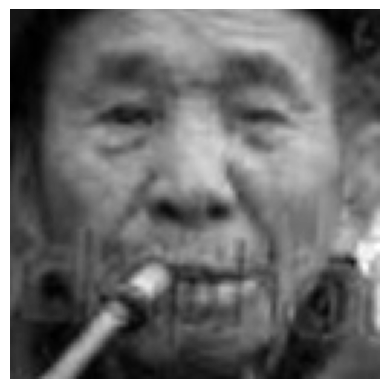

In [26]:
image_index = 50
print("Original Age:", y_test[image_index]) 
pred = model.predict(X_test[image_index].reshape(1, 128, 128, 1)) 
print("Predicted Age:", int(pred[0][0]))
plt.axis('off')
plt.imshow(X_test[image_index].reshape(128, 128), cmap='gray')

In [27]:
def make_test(images):
    features = []
    
    img = load_img(images, grayscale=True)
    img = img.resize((128, 128), Image.LANCZOS)
    img = np.array(img)
    features.append(img)
        
    features = np.array(features)
    # ignore this step if using RGB
    features = features.reshape(len(features), 128, 128, 1)
    return features

In [28]:
test1=make_test('test.jpg')

In [29]:
test1 = test1/255.0

In [30]:
out_test1 = model.predict(test1) 

1/1 [==============================] - 0s 318ms/step


In [31]:
print(out_test1)

[[1.]]


In [ ]:
# بارگذاری مدل تشخیص چهره
detector = cv2.CascadeClassifier('models/haarcascade_frontalface_default.xml')

# باز کردن دوربین
cam = cv2.VideoCapture(0)

while True:
    ret, frame = cam.read()
    frame = cv2.flip(frame, 1)

    if ret:
        faces = detector.detectMultiScale(frame, 1.3, 5)
        for x, y, w, h in faces:
            face = frame[y:y + h, x:x + w]
            face = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
            face = cv2.resize(face, (128, 128))
            face = face / 255.0
            face = face.reshape(1, 128, 128, 1)

            # پیش‌بینی سن
            age = model.predict(face, verbose=0)
            predicted_age = int(age[0][0])

            # نمایش در ترمینال
            print(f"Predicted Age: {predicted_age}")

            # نمایش روی فریم ویدیو
            cv2.rectangle(frame, (x, y), (x + w, y + h), (255, 0, 0), 2)
            cv2.rectangle(frame, (x, y + h), (x + w, y + h + 30), (255, 0, 0), -1)
            cv2.putText(frame, f"Age: {predicted_age}", (x + 10, y + h + 20),
            cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

        cv2.imshow('Age Detection - Press ESC to Exit', frame)


    # خروج با کلید ESC
    if cv2.waitKey(500) == 27:
        break

cam.release()
cv2.destroyAllWindows()

NameError: name 'model' is not defined

: 